In [9]:
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

# Carichiamo il dataset del parcheggio
parking = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\Parkeerdruk_buurten.json")
print(f"Elementi caricati: {len(parking)}")
print(parking.columns.tolist())
parking.head()

Elementi caricati: 1840
['BRT', 'SDC', 'Periode', 'Dagdeel', 'Cap_open', 'Bez_open', 'Fout', 'Object', 'Bez_tot', 'Netto_PKD', 'Bruto_PKD', 'geometry']


,BRT,SDC,Periode,Dagdeel,Cap_open,Bez_open,Fout,Object,Bez_tot,Netto_PKD,Bruto_PKD,geometry
0,A00a Kop Zeedijk,A,202305,weekend nacht,17,1,0,0,1,6,6,"POLYGON ((52.37659 4.90325, 52.37669 4.90297, ..."
1,A00b Oude Kerk e.o.,A,202305,weekend nacht,6,3,0,0,3,50,50,"POLYGON ((52.37475 4.8994, 52.37479 4.89923, 5..."
2,A00c Burgwallen Oost,A,202305,weekend nacht,40,20,1,0,21,50,52,"POLYGON ((52.37349 4.90093, 52.37417 4.90126, ..."
3,A00d Nes e.o.,A,202305,weekend nacht,15,7,0,0,7,47,47,"POLYGON ((52.37186 4.89587, 52.3722 4.89482, 5..."
4,A00e BG-terrein e.o.,A,202305,weekend nacht,69,43,1,0,44,62,64,"POLYGON ((52.37099 4.89875, 52.37144 4.89706, ..."


In [10]:
print("Periodi disponibili:")
print(parking['Periode'].value_counts())
print("\nFasce orarie:")
print(parking['Dagdeel'].value_counts())

Periodi disponibili:
Periode
202502-202503    221
202510-202511    212
202501-202503    209
202506-202509    208
202602-202603    202
202403-202404    190
202509           127
202305-202306     77
202503            69
202305            64
0                 57
202301-202302     47
202406            40
202303-202305     33
202305-202307     29
202409-202411     19
202307-202311     14
202307-202309      7
202307             7
202404-202406      4
202405-202406      4
Name: count, dtype: int64

Fasce orarie:
Dagdeel
doordeweeks avond     518
doordeweeks middag    518
zaterdagmiddag        440
zondagmiddag          252
weekend nacht          70
zondagavond            38
doordeweeks nacht       4
Name: count, dtype: int64


In [11]:
# Prendiamo i dati più recenti - pomeriggio feriale
parking_filtered = parking[
    (parking['Dagdeel'] == 'doordeweeks middag') &
    (parking['Netto_PKD'] > 0) &
    (parking['Periode'] == '202502-202503')
].copy()

print(f"Zone analizzate: {len(parking_filtered)}")
print(f"\nPressione media: {parking_filtered['Netto_PKD'].mean():.1f}%")
print(f"Pressione massima: {parking_filtered['Netto_PKD'].max():.1f}%")
print(f"Pressione minima: {parking_filtered['Netto_PKD'].min():.1f}%")
print(f"\nTop 5 zone più congestionate:")
print(parking_filtered[['BRT', 'Netto_PKD']].sort_values('Netto_PKD', ascending=False).head())

Zone analizzate: 74

Pressione media: 184.6%
Pressione massima: 8888.0%
Pressione minima: 9.0%

Top 5 zone più congestionate:
                        BRT  Netto_PKD
713    KE01 Frans Halsbuurt       8888
707        KD05 Museumplein        100
754        KP04 Zuidas-Zuid        100
716  KE04 Sarphatiparkbuurt         92
706    KD04 P.C. Hooftbuurt         92


In [12]:
# Rimuoviamo i valori anomali (Fout = 1 significa errore)
parking_clean = parking_filtered[
    (parking_filtered['Fout'] == 0) &
    (parking_filtered['Netto_PKD'] <= 200)
].copy()

print(f"Zone dopo pulizia: {len(parking_clean)}")
print(f"\nPressione media: {parking_clean['Netto_PKD'].mean():.1f}%")
print(f"Pressione massima: {parking_clean['Netto_PKD'].max():.1f}%")
print(f"Pressione minima: {parking_clean['Netto_PKD'].min():.1f}%")
print(f"\nTop 10 zone più congestionate:")
print(parking_clean[['BRT', 'Netto_PKD']].sort_values('Netto_PKD', ascending=False).head(10))

Zone dopo pulizia: 9

Pressione media: 52.0%
Pressione massima: 100.0%
Pressione minima: 9.0%

Top 10 zone più congestionate:
                            BRT  Netto_PKD
707            KD05 Museumplein        100
752                    KP02 RAI         79
696  KA05 Aalsmeerwegbuurt-Oost         73
746         KM02 Rijnbuurt-West         59
749              KM05 Zorgvlied         58
730        KH06 IJsbaanpad e.o.         43
757              KQ02 Zuiderhof         35
756        KQ01 Amsterdamse Bos         12
765             KR04 Amstelpark          9


In [13]:
# Proviamo con doordeweeks avond che ha più record
parking_filtered2 = parking[
    (parking['Dagdeel'] == 'doordeweeks avond') &
    (parking['Netto_PKD'] > 0) &
    (parking['Netto_PKD'] < 500) &
    (parking['Fout'] == 0)
].copy()

print(f"Zone analizzate: {len(parking_filtered2)}")
print(f"\nPressione media: {parking_filtered2['Netto_PKD'].mean():.1f}%")
print(f"Pressione massima: {parking_filtered2['Netto_PKD'].max():.1f}%")
print(f"\nTop 10 zone più congestionate:")
print(parking_filtered2[['BRT', 'Netto_PKD', 'Periode']].sort_values('Netto_PKD', ascending=False).head(10))

Zone analizzate: 112

Pressione media: 54.3%
Pressione massima: 95.0%

Top 10 zone più congestionate:
                                BRT  Netto_PKD        Periode
178               AK08 Kazernebuurt         95  202403-202404
128        AB08 Groenmarktkadebuurt         93  202403-202404
132           AC01 Langestraat e.o.         93  202403-202404
641      KE03 Hercules Seghersbuurt         93  202502-202503
638           KD10 Harmoniehofbuurt         92  202502-202503
149                  AF06 Uilenburg         91  202403-202404
136                  AD02 Hemelrijk         91  202403-202404
175           AK05 Czaar Peterbuurt         90  202403-202404
1359  EB05 Spaarndammerbuurt-Midden         90  202506-202509
1377    EF01 Robert Scottbuurt-Oost         89  202506-202509


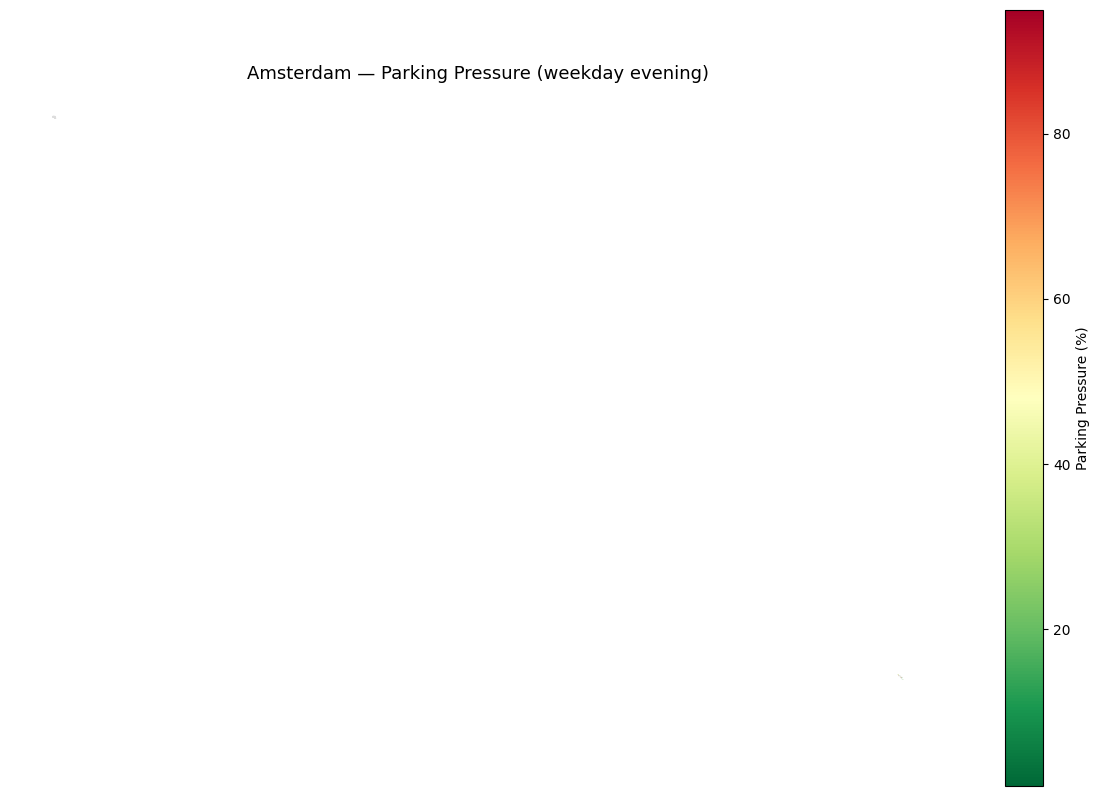

In [14]:
import matplotlib.pyplot as plt

# Convertiamo in EPSG:28992
parking_filtered2 = parking_filtered2.to_crs("EPSG:28992")

# Carichiamo i quartieri come sfondo
buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
buurten_proj = buurten.to_crs("EPSG:28992")

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Sfondo
buurten_proj.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

# Pressione parcheggio
parking_filtered2.plot(
    column='Netto_PKD',
    cmap='RdYlGn_r',
    ax=ax,
    legend=True,
    alpha=0.8,
    legend_kwds={'label': 'Parking Pressure (%)', 'shrink': 0.8}
)

ax.set_title('Amsterdam — Parking Pressure (weekday evening)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_parking_pressure.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
from shapely.ops import transform

# Invertiamo x e y nelle geometrie
parking_filtered2 = parking[
    (parking['Dagdeel'] == 'doordeweeks avond') &
    (parking['Netto_PKD'] > 0) &
    (parking['Netto_PKD'] < 500) &
    (parking['Fout'] == 0)
].copy()

# Swap delle coordinate (lat,lng -> lng,lat)
parking_filtered2['geometry'] = parking_filtered2['geometry'].apply(
    lambda geom: transform(lambda x, y: (y, x), geom)
)

# Impostiamo il CRS corretto e riproiettiamo
parking_filtered2 = parking_filtered2.set_crs("EPSG:4326")
parking_filtered2 = parking_filtered2.to_crs("EPSG:28992")

print(f"Bounds dopo correzione: {parking_filtered2.total_bounds}")

Bounds dopo correzione: [110188.38214209 476708.6194241  135932.86083667 493893.63315556]


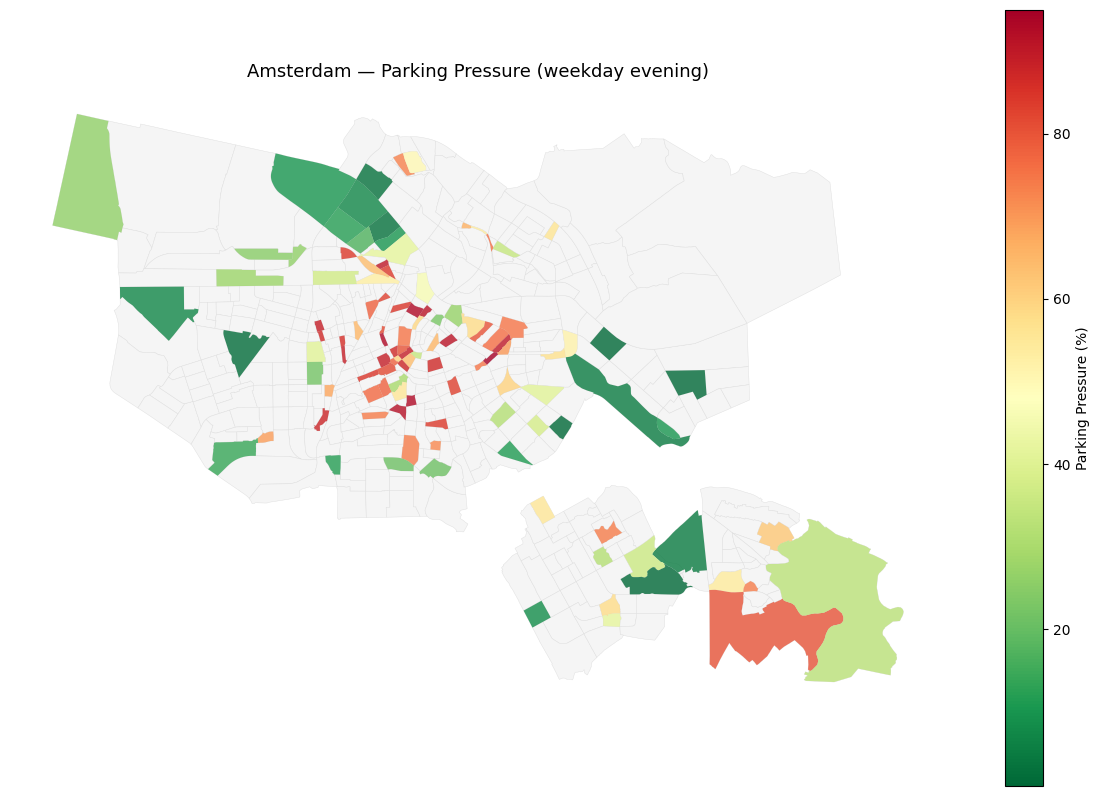

In [16]:
import matplotlib.pyplot as plt

buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
buurten_proj = buurten.to_crs("EPSG:28992")

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

buurten_proj.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

parking_filtered2.plot(
    column='Netto_PKD',
    cmap='RdYlGn_r',
    ax=ax,
    legend=True,
    alpha=0.8,
    legend_kwds={'label': 'Parking Pressure (%)', 'shrink': 0.8}
)

ax.set_title('Amsterdam — Parking Pressure (weekday evening)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_parking_pressure.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Controlliamo i bounds di alcuni poligoni individuali prima dello swap
parking_test = parking[
    (parking['Dagdeel'] == 'doordeweeks avond') &
    (parking['Netto_PKD'] > 0) &
    (parking['Netto_PKD'] < 500) &
    (parking['Fout'] == 0)
].copy()

# Guardiamo i bounds di ogni geometria (prima dello swap)
for idx, row in parking_test.head(10).iterrows():
    b = row.geometry.bounds
    print(f"{row['BRT'][:30]:30s} bounds: {b}")

AA03 Westerdokseiland          bounds: (52.3801424, 4.8901799, 52.3886909, 4.8987674)
AB03 Anjeliersbuurt-Noord      bounds: (52.3776678, 4.8791773, 52.3807262, 4.8884307)
AB06 Marnixbuurt-Midden        bounds: (52.3718873, 4.8744342, 52.3740752, 4.8769215)
AB08 Groenmarktkadebuurt       bounds: (52.3685015, 4.8744976, 52.3723126, 4.8782902)
AB11 Passeerdersgrachtbuurt    bounds: (52.3654917, 4.8790699, 52.3687657, 4.8827928)
AC01 Langestraat e.o.          bounds: (52.3763231, 4.8862007, 52.3805202, 4.8939981)
AC03 Felix Meritisbuurt        bounds: (52.368754, 4.8826089, 52.3740635, 4.8888499)
AC04 Leidsegracht-Noord        bounds: (52.3661753, 4.8824191, 52.3689299, 4.8880544)
AD02 Hemelrijk                 bounds: (52.376608, 4.8920767, 52.3798544, 4.8977076)
AD04 Spuistraat-Noord          bounds: (52.3731727, 4.8888499, 52.3770304, 4.8941947)


In [18]:
# Controlliamo la validità delle geometrie dopo lo swap
print(f"Geometrie totali: {len(parking_filtered2)}")
print(f"Geometrie valide: {parking_filtered2.geometry.is_valid.sum()}")
print(f"Geometrie non valide: {(~parking_filtered2.geometry.is_valid).sum()}")

# Mostriamo quali sono invalide
invalid = parking_filtered2[~parking_filtered2.geometry.is_valid]
print("\nZone con geometria non valida:")
print(invalid['BRT'].tolist())

Geometrie totali: 112
Geometrie valide: 112
Geometrie non valide: 0

Zone con geometria non valida:
[]


In [19]:
# Calcoliamo area e rapporto larghezza/altezza per identificare forme insolite
parking_filtered2['area_km2'] = parking_filtered2.geometry.area / 1_000_000
parking_filtered2['perimetro_km'] = parking_filtered2.geometry.length / 1000

# Un indice di "compattezza" - più è basso, più la forma è allungata/irregolare
parking_filtered2['compattezza'] = (4 * 3.14159 * parking_filtered2['area_km2']) / (parking_filtered2['perimetro_km']**2)

print("Le 5 forme più allungate/irregolari:")
print(parking_filtered2[['BRT', 'area_km2', 'compattezza']].sort_values('compattezza').head())

Le 5 forme più allungate/irregolari:
                             BRT   area_km2  compattezza
1134    NF01 Buiksloterdijk-West   0.026450     0.229660
1135    NF02 Buiksloterdijk-Oost   0.026861     0.232716
429    MH06 Bovendiep/Diemerpark   2.399931     0.276258
908        SE01 Aetsveldsepolder   5.511757     0.304066
911   SE04 Oostelijke Vechtoever  10.946986     0.355012


In [20]:
# Carichiamo entrambe le fasce orarie
parking_middag = parking[
    (parking['Dagdeel'] == 'doordeweeks middag') &
    (parking['Netto_PKD'] > 0) &
    (parking['Netto_PKD'] < 500) &
    (parking['Fout'] == 0)
][['BRT', 'Netto_PKD', 'Periode']].copy()
parking_middag.columns = ['BRT', 'PKD_middag', 'Periode_middag']

parking_avond = parking[
    (parking['Dagdeel'] == 'doordeweeks avond') &
    (parking['Netto_PKD'] > 0) &
    (parking['Netto_PKD'] < 500) &
    (parking['Fout'] == 0)
][['BRT', 'Netto_PKD', 'Periode']].copy()
parking_avond.columns = ['BRT', 'PKD_avond', 'Periode_avond']

# Uniamo per zona
confronto = parking_middag.merge(parking_avond, on='BRT', how='inner')

# Calcoliamo la differenza
confronto['differenza'] = confronto['PKD_avond'] - confronto['PKD_middag']

print(f"Zone con entrambi i dati: {len(confronto)}")
print(f"\nZone più residenziali (sera >> giorno):")
print(confronto.sort_values('differenza', ascending=False)[['BRT', 'PKD_middag', 'PKD_avond', 'differenza']].head())
print(f"\nZone più commerciali/turistiche (giorno >> sera):")
print(confronto.sort_values('differenza')[['BRT', 'PKD_middag', 'PKD_avond', 'differenza']].head())

Zone con entrambi i dati: 60

Zone più residenziali (sera >> giorno):
                            BRT  PKD_middag  PKD_avond  differenza
42      NA06 Circus/Kermisbuurt          43         73          30
51        EB09 Westergasfabriek          27         53          26
23          MH04 Baaibuurt-West          29         52          23
50  EB03 Zaanstraat emplacement          42         64          22
28      MN04 Science Park-Noord          19         41          22

Zone più commerciali/turistiche (giorno >> sera):
                            BRT  PKD_middag  PKD_avond  differenza
31             KD05 Museumplein         100         30         -70
33               KM05 Zorgvlied          58         21         -37
40             TK02 Gaasperpark          67         36         -31
17  BB03 Minervahaven-Noordoost          29          3         -26
43               NA07 Molenwijk          74         50         -24
